# Insights + task-run fetch

Exports **`data/insights_with_recommendations_data.csv`** (gitignored).

Requires `DATABASE_URL`. After fetch, run `scripts/add_recommendations.py` for the output CSV used by `tuning_framework_test.ipynb`.


In [41]:
%pip install psycopg2-binary sqlalchemy pandas

Note: you may need to restart the kernel to use updated packages.


In [42]:
from pathlib import Path
import pandas as pd
from sqlalchemy import create_engine

In [ ]:
import os
import random
import time
from datetime import datetime, timedelta, timezone
from pathlib import Path

import pandas as pd
from sqlalchemy import create_engine, text

DATABASE_URL = os.environ.get("DATABASE_URL")
if not DATABASE_URL:
    raise RuntimeError("Set DATABASE_URL in your environment (see .env.example)")

ROOT = Path.cwd()
if not (ROOT / "data" / "case_studies").is_dir() and (ROOT.parent / "data" / "case_studies").is_dir():
    ROOT = ROOT.parent

DATA_DIR = ROOT / "data"
OUTPUT_CSV = DATA_DIR / "insights_with_recommendations_data.csv"
CHECKPOINT_DIR = DATA_DIR / "fetch_checkpoints"

LOOKBACK_DAYS = 7
CHUNK_DAYS = 1
MAX_RETRIES = 10
STATEMENT_TIMEOUT_S = 1800
CONTINUE_ON_FAILURE = True
SUBCHUNK_HOURS = (12, 6)
METRICS_BATCH_SIZE = 50
METRICS_BATCH_RETRIES = 8

CONNECT_ARGS = {
    "connect_timeout": 60,
    "keepalives": 1,
    "keepalives_idle": 30,
    "keepalives_interval": 10,
    "keepalives_count": 5,
}

RECORD_COLUMNS = [
    "input_records_read",
    "output_records_written",
    "shuffle_records_read",
    "shuffle_records_written",
]

_RECORD_METRICS_AGG = """
    SELECT
        m.task_id,
        MAX(m.metric_value) FILTER (WHERE mc.metric_type = 'input_records_read')       AS input_records_read,
        MAX(m.metric_value) FILTER (WHERE mc.metric_type = 'output_records_written')   AS output_records_written,
        MAX(m.metric_value) FILTER (WHERE mc.metric_type = 'shuffle_records_read')     AS shuffle_records_read,
        MAX(m.metric_value) FILTER (WHERE mc.metric_type = 'shuffle_records_written')  AS shuffle_records_written
    FROM metrics AS m
    JOIN (
        SELECT metric_id, metric_type
        FROM metrics_conf
        WHERE metric_type IN (
            'input_records_read',
            'output_records_written',
            'shuffle_records_read',
            'shuffle_records_written'
        )
    ) AS mc ON mc.metric_id = m.metric_id
"""

TASKS_QUERY = text("""
SELECT
    i.insight_id,
    i.type                                                                  AS insight_type,
    i.impact_cost,
    i.impact_unit,
    i.insights_payload,
    t.app_id,
    t.task_name,
    t.task_id,
    t.app_pit,
    t.start_time,
    t.end_time,
    t.status,
    te.task__duration                                                       AS task_duration_seconds,
    te.executors__run_time__used                                            AS executors_run_time_seconds,
    te.executors__tasks_duration__used                                      AS executors_tasks_duration_seconds,
    te.task__vcore_time__used                                               AS vcore_seconds_used,
    te.task__vcore_time__allocated                                          AS vcore_seconds_allocated,
    te.executors__vcore_time__used                                          AS executors_vcore_seconds_used,
    te.executors__vcore_time__allocated                                     AS executors_vcore_seconds_allocated,
    te.executors__cpu_time__used                                            AS executors_cpu_time_seconds,
    te.executors__used_vcore_time_of_retried_tasks                          AS vcore_seconds_wasted_on_retries,
    te.task__memory_time__allocated                                         AS memory_gb_seconds_allocated,
    te.executors__memory_time__used                                         AS memory_gb_seconds_used,
    te.executor__memory__allocated                                          AS executor_total_memory_gb,
    te.executor__memory_heap__allocated                                     AS executor_heap_memory_allocated_gb,
    te.executor__memory_heap__max_used                                      AS executor_heap_memory_peak_gb,
    te.executor__memory_off_heap__allocated                                 AS executor_off_heap_memory_allocated_gb,
    te.executor__memory_off_heap__max_used                                  AS executor_off_heap_memory_peak_gb,
    te.driver__memory__allocated                                            AS driver_total_memory_allocated_gb,
    te.driver__memory__max_used                                             AS driver_memory_peak_gb,
    te.driver__heap_memory__allocated                                       AS driver_heap_memory_allocated_gb,
    te.driver__heap_memory__max_used                                        AS driver_heap_memory_peak_gb,
    te.task__total_io_bytes                                                 AS total_io_bytes,
    te.task__disk_bytes_spilled                                             AS disk_bytes_spilled,
    CASE
        WHEN te.task__total_io_bytes > 0
        THEN 2.0 * te.task__disk_bytes_spilled / te.task__total_io_bytes
        ELSE 0
    END                                                                     AS spill_ratio,
    te.executors__jvm_gc_time                                               AS executors_jvm_gc_seconds,
    te.task__executors_dynamic_allocation_min_executors__param              AS spark_dynamic_alloc_min_executors,
    te.task__executors_dynamic_allocation_max_executors__param              AS spark_dynamic_alloc_max_executors,
    te.task__executor_instances__param                                      AS spark_executor_instances,
    te.executor__memory_heap__allocated                                     AS spark_executor_memory_gb,
    te.executor__memory_off_heap__allocated                                 AS spark_executor_memory_overhead_gb,
    te.driver__heap_memory__allocated                                       AS spark_driver_memory_gb,
    te.driver__cores                                                        AS spark_driver_cores,
    te.task__shuffle_partitions__param                                      AS spark_shuffle_partitions,
    te.task__task_cpus__param                                               AS spark_task_cpus,
    te.executor__cores                                                      AS spark_executor_cores,
    te.task__dynamic_is_allocation_enabled__param                           AS is_dynamic_allocation,
    te.cluster_min_workers,
    te.cluster_max_workers,
    te.cluster_workers,
    te.workers_availability                                                 AS aws_availability,
    te.worker_type                                                          AS worker_instance_type,
    te.driver_type                                                          AS driver_instance_type,
    te.cloud_provider,
    GREATEST(
        (te.executor__memory__allocated / NULLIF(ts.machine_memory_to_vcore_ratio, 0) - te.executor__cores)
        * te.task__duration, 0
    )                                                                       AS executors_vcores_unused,
    (
        (
            te.task__vcore_time__allocated
            + GREATEST(
                (te.executor__memory__allocated / NULLIF(ts.machine_memory_to_vcore_ratio, 0) - te.executor__cores)
                * te.task__duration, 0
              )
        ) * ts.vcore_price / 3600
        + te.task__memory_time__allocated * ts.memory_price / 3600
    )                                                                       AS run_cost_usd,
    ts.vcore_price,
    ts.memory_price,
    ts.machine_memory_to_vcore_ratio,
    CASE
        WHEN i.impact_unit = 'VCore'        THEN i.impact_cost * ts.vcore_price / 3600
        WHEN i.impact_unit = 'GB'           THEN i.impact_cost * ts.memory_price / 3600
        WHEN i.impact_unit = 'file-listing' THEN i.impact_cost * ts.file_listing_price / 1000
        WHEN i.impact_unit = 'dollar'       THEN i.impact_cost
    END                                                                     AS insight_usd_cost
FROM tasks AS t
JOIN task_enrichments AS te ON te.task_id = t.task_id
JOIN tenant_settings AS ts ON ts.tenant_id = t.tenant_id
LEFT JOIN insights AS i
    ON i.app_id = t.app_id
    AND i.task_name = t.task_name
    AND i.type != 'task_profile'
WHERE t.start_time >= :start_ts
  AND t.start_time < :end_ts
""")

METRICS_BY_RANGE_QUERY = text(
    _RECORD_METRICS_AGG
    + """
    JOIN tasks AS t_rec ON t_rec.task_id = m.task_id
    WHERE t_rec.start_time >= :start_ts
      AND t_rec.start_time < :end_ts
    GROUP BY m.task_id
"""
)

METRICS_BY_TASK_IDS_QUERY = text(
    _RECORD_METRICS_AGG
    + """
    WHERE m.task_id = ANY(:task_ids)
    GROUP BY m.task_id
"""
)

RETRYABLE_MARKERS = (
    "SerializationFailure",
    "conflict with recovery",
    "SSL connection has been closed",
    "connection already closed",
    "server closed the connection",
    "OperationalError",
    "DatabaseError",
    "timeout",
    "timed out",
    "could not connect",
    "connection reset",
    "canceling statement",
    "too many connections",
)


def is_retryable(exc: Exception) -> bool:
    msg = f"{type(exc).__name__}: {getattr(exc, 'orig', exc)}"
    msg_lower = msg.lower()
    return any(marker.lower() in msg_lower for marker in RETRYABLE_MARKERS)


def _exc_detail(exc: Exception) -> str:
    orig = getattr(exc, "orig", None)
    return f"{type(exc).__name__}: {orig or exc}"


def checkpoint_path(start_ts: datetime, end_ts: datetime) -> Path:
    return CHECKPOINT_DIR / f"{start_ts.date()}_{end_ts.date()}.csv"


def _make_engine():
    return create_engine(
        DATABASE_URL,
        pool_pre_ping=True,
        pool_size=1,
        max_overflow=0,
        connect_args=CONNECT_ARGS,
    )


def _read_sql_with_retry(query, params: dict, *, max_retries: int = MAX_RETRIES, label: str = "query") -> pd.DataFrame:
    last_exc: Exception | None = None
    for attempt in range(1, max_retries + 1):
        engine = _make_engine()
        try:
            with engine.connect() as conn:
                conn.execute(text(f"SET statement_timeout = '{STATEMENT_TIMEOUT_S}s'"))
                return pd.read_sql(query, conn, params=params)
        except Exception as exc:
            last_exc = exc
            if not is_retryable(exc) or attempt == max_retries:
                raise
            wait_s = min(120, 2**attempt + random.uniform(0, 3))
            print(f"  {label} retry {attempt}/{max_retries} in {wait_s:.0f}s — {_exc_detail(exc)}")
            time.sleep(wait_s)
        finally:
            engine.dispose()
    raise last_exc if last_exc else RuntimeError("unreachable")


def fetch_record_metrics_by_range(start_ts: datetime, end_ts: datetime) -> pd.DataFrame:
    return _read_sql_with_retry(
        METRICS_BY_RANGE_QUERY,
        {"start_ts": start_ts, "end_ts": end_ts},
        label="metrics-range",
    )


def fetch_record_metrics_batched(task_ids: list[int]) -> pd.DataFrame:
    if not task_ids:
        return pd.DataFrame(columns=["task_id"] + RECORD_COLUMNS)
    parts: list[pd.DataFrame] = []
    n_batches = (len(task_ids) + METRICS_BATCH_SIZE - 1) // METRICS_BATCH_SIZE
    for batch_idx, offset in enumerate(range(0, len(task_ids), METRICS_BATCH_SIZE), start=1):
        batch_ids = task_ids[offset : offset + METRICS_BATCH_SIZE]
        for attempt in range(1, METRICS_BATCH_RETRIES + 1):
            engine = _make_engine()
            try:
                with engine.connect() as conn:
                    conn.execute(text(f"SET statement_timeout = '{STATEMENT_TIMEOUT_S}s'"))
                    part = pd.read_sql(METRICS_BY_TASK_IDS_QUERY, conn, params={"task_ids": batch_ids})
                parts.append(part)
                print(f"    metrics batch {batch_idx}/{n_batches}: {len(part):,} rows")
                break
            except Exception as exc:
                if not is_retryable(exc) or attempt == METRICS_BATCH_RETRIES:
                    raise
                wait_s = min(60, 2**attempt + random.uniform(0, 2))
                print(f"    metrics batch {batch_idx}/{n_batches} retry {attempt}/{METRICS_BATCH_RETRIES} in {wait_s:.0f}s")
                time.sleep(wait_s)
            finally:
                engine.dispose()
    return pd.concat(parts, ignore_index=True) if parts else pd.DataFrame(columns=["task_id"] + RECORD_COLUMNS)


def attach_record_metrics(tasks: pd.DataFrame, start_ts: datetime, end_ts: datetime) -> pd.DataFrame:
    if tasks.empty:
        for col in RECORD_COLUMNS:
            tasks[col] = pd.NA
        return tasks
    try:
        metrics = fetch_record_metrics_by_range(start_ts, end_ts)
        print(f"    metrics (date range): {len(metrics):,} rows")
    except Exception as exc:
        print(f"    metrics range query failed ({_exc_detail(exc)}); batching by task_id…")
        task_ids = tasks["task_id"].dropna().astype(int).unique().tolist()
        metrics = fetch_record_metrics_batched(task_ids)
    return tasks.merge(metrics, on="task_id", how="left")


def fetch_chunk_once(start_ts: datetime, end_ts: datetime) -> pd.DataFrame:
    tasks = _read_sql_with_retry(TASKS_QUERY, {"start_ts": start_ts, "end_ts": end_ts}, label="tasks")
    print(f"    tasks: {len(tasks):,} rows")
    return attach_record_metrics(tasks, start_ts, end_ts)


def fetch_range(start_ts: datetime, end_ts: datetime) -> pd.DataFrame:
    span_hours = (end_ts - start_ts).total_seconds() / 3600
    try:
        return fetch_chunk_once(start_ts, end_ts)
    except Exception as exc:
        for hours in SUBCHUNK_HOURS:
            if span_hours <= hours:
                continue
            print(f"  split into {hours}h sub-chunks after {_exc_detail(exc)}")
            parts: list[pd.DataFrame] = []
            sub = start_ts
            while sub < end_ts:
                sub_end = min(sub + timedelta(hours=hours), end_ts)
                parts.append(fetch_chunk_once(sub, sub_end))
                sub = sub_end
            return pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()
        raise


CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
range_end = datetime.now(timezone.utc)
range_start = range_end - timedelta(days=LOOKBACK_DAYS)

chunks: list[pd.DataFrame] = []
failed_ranges: list[tuple[datetime, datetime, str]] = []
cursor = range_start
while cursor < range_end:
    chunk_end = min(cursor + timedelta(days=CHUNK_DAYS), range_end)
    cp = checkpoint_path(cursor, chunk_end)

    if cp.exists():
        chunk = pd.read_csv(cp, low_memory=False)
        print(f"{cursor.date()} → {chunk_end.date()}: {len(chunk):,} rows (checkpoint)")
    else:
        try:
            print(f"{cursor.date()} → {chunk_end.date()}: fetching…")
            chunk = fetch_range(cursor, chunk_end)
            chunk.to_csv(cp, index=False)
            print(f"{cursor.date()} → {chunk_end.date()}: {len(chunk):,} rows (saved)")
        except Exception as exc:
            msg = _exc_detail(exc)
            failed_ranges.append((cursor, chunk_end, msg))
            print(f"{cursor.date()} → {chunk_end.date()}: FAILED — {msg}")
            if not CONTINUE_ON_FAILURE:
                raise
            cursor = chunk_end
            continue

    chunks.append(chunk)
    cursor = chunk_end

if not chunks:
    raise RuntimeError("No checkpoint chunks loaded.")

data = pd.concat(chunks, ignore_index=True)
data = data.sort_values(["start_time", "insight_id"], na_position="last")
data.to_csv(OUTPUT_CSV, index=False)
print(f"Saved {len(data):,} rows to {OUTPUT_CSV.resolve()}")

if failed_ranges:
    print(f"\nMissing {len(failed_ranges)} chunk(s) — re-run to retry:")
    for start_ts, end_ts, msg in failed_ranges:
        print(f"  {start_ts.date()} → {end_ts.date()}  ({msg})")

2026-05-20 → 2026-05-21: fetching…


In [ ]:
data = pd.read_csv('data/insights_with_recommendations_output.csv')

/var/folders/8n/hmc4wv1s3vj_hbchsdtzmvym0000gn/T/ipykernel_61332/3156587084.py:1: DtypeWarning: Columns (0: spark_shuffle_partitions, 1: spark.sql.shuffle.partitions) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('insights_with_recommendations_output.csv')


In [ ]:
data.shape

(32667, 81)

In [ ]:
data.task_duration_seconds.describe()

count     32667.000000
mean       1826.848435
std        6779.479968
min           0.000000
25%         125.023000
50%         373.557000
75%        1084.518500
max      213001.238000
Name: task_duration_seconds, dtype: float64

## Distribution exploration

Each row is one **task run** joined to zero or more **insights** (same `task_id` repeated when multiple insights apply).

| Question | Unit counted | Grouped by |
|----------|--------------|------------|
| Tasks per app | distinct `task_name` | `app_id` |
| Insights per task | distinct `insight_id` (non-null) | `app_id` + `task_name` |
| Runs per task | distinct `task_id` | `app_id` + `task_name` |

Note: you may need to restart the kernel to use updated packages.
### 1. How many tasks per app_id?


,entities,mean,std,min,p25,median,p75,p90,p95,p99,max
tasks_per_app,1892.0,2.26797,6.161975,1.0,1.0,1.0,1.0,4.0,8.0,20.09,150.0



Top 10 apps by task count:


,task_count
app_id,
12709,150
12704,140
12703,81
11901,41
1227,37
1279,35
6911,33
13148,33
6902,33


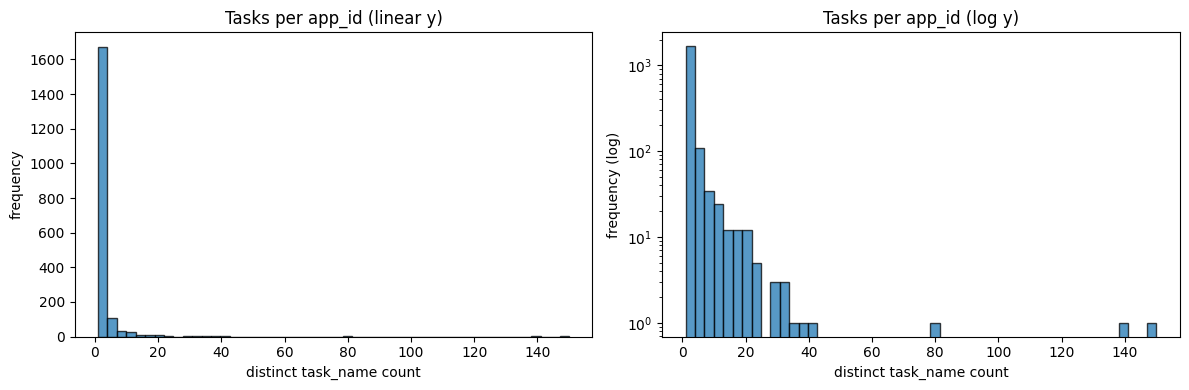

### 2. How many insights per task?


,entities,mean,std,min,p25,median,p75,p90,p95,p99,max
insights_per_task,4291.0,0.090422,0.334119,0.0,0.0,0.0,0.0,0.0,1.0,2.0,3.0



Tasks with zero insights: 3,960 / 4,291


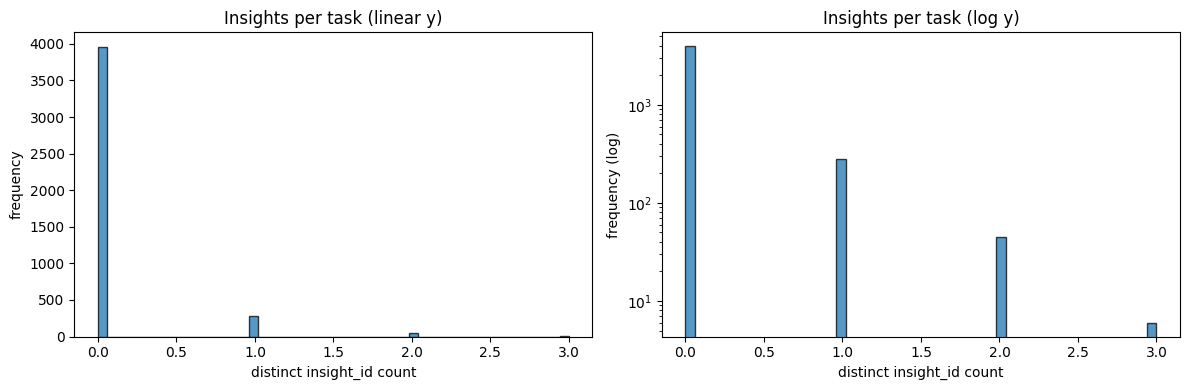

### 3. How many task runs per task?


,entities,mean,std,min,p25,median,p75,p90,p95,p99,max
runs_per_task,4291.0,6.727569,18.23628,1.0,1.0,4.0,5.0,6.0,17.0,105.0,327.0



Top 10 tasks by run count:


,app_id,task_name,run_count
0,268,AUDIENCES_3P_OFFLINE,327
1,1239,VERTICA_BIDS,324
2,267,CATEGORIES_OFFLINE,278
3,1035,IMPRESSION,219
4,22676,compute,203
5,13692,compute,202
6,13834,listing_consolidated_cosmos,199
7,13693,capforce_opportunity_load_utility,196
8,458,ACTION,129
9,473,KEY_VALUES_OFFLINE,118


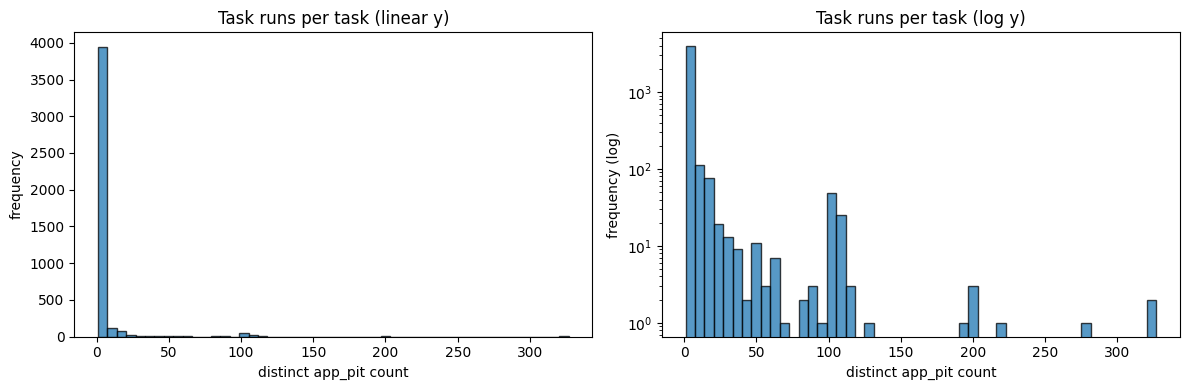

In [7]:
%pip install -q matplotlib

import matplotlib.pyplot as plt

TASK_KEY = ["app_id", "task_name"]


def distribution_summary(counts: pd.Series, label: str) -> pd.Series:
    """Summary stats for a count distribution."""
    return pd.Series(
        {
            "entities": len(counts),
            "mean": counts.mean(),
            "std": counts.std(),
            "min": counts.min(),
            "p25": counts.quantile(0.25),
            "median": counts.median(),
            "p75": counts.quantile(0.75),
            "p90": counts.quantile(0.90),
            "p95": counts.quantile(0.95),
            "p99": counts.quantile(0.99),
            "max": counts.max(),
        },
        name=label,
    )


def plot_distribution(counts: pd.Series, title: str, xlabel: str) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].hist(counts, bins=50, edgecolor="black", alpha=0.75)
    axes[0].set_title(f"{title} (linear y)")
    axes[0].set_xlabel(xlabel)
    axes[0].set_ylabel("frequency")

    axes[1].hist(counts, bins=50, edgecolor="black", alpha=0.75)
    axes[1].set_yscale("log")
    axes[1].set_title(f"{title} (log y)")
    axes[1].set_xlabel(xlabel)
    axes[1].set_ylabel("frequency (log)")

    plt.tight_layout()
    plt.show()


# 1) Tasks per app_id
tasks_per_app = data.groupby("app_id")["task_name"].nunique()

print("### 1. How many tasks per app_id?")
display(distribution_summary(tasks_per_app, "tasks_per_app").to_frame().T)
print("\nTop 10 apps by task count:")
display(tasks_per_app.sort_values(ascending=False).head(10).to_frame("task_count"))
plot_distribution(tasks_per_app, "Tasks per app_id", "distinct task_name count")

# 2) Insights per task (0 for tasks with no insights in the extract)
insight_rows = data[data["insight_id"].notna()]
insights_per_task = insight_rows.groupby(TASK_KEY)["insight_id"].nunique()
all_tasks = data[TASK_KEY].drop_duplicates().set_index(TASK_KEY)
insights_per_task = all_tasks.join(
    insights_per_task.rename("insight_count"), how="left"
)["insight_count"].fillna(0).astype(int)

print("### 2. How many insights per task?")
display(distribution_summary(insights_per_task, "insights_per_task").to_frame().T)
print(f"\nTasks with zero insights: {(insights_per_task == 0).sum():,} / {len(insights_per_task):,}")
plot_distribution(insights_per_task, "Insights per task", "distinct insight_id count")

# 3) Task runs per task
runs_per_task = data.groupby(TASK_KEY)["app_pit"].nunique()

print("### 3. How many task runs per task?")
display(distribution_summary(runs_per_task, "runs_per_task").to_frame().T)
print("\nTop 10 tasks by run count:")
display(
    runs_per_task.sort_values(ascending=False)
    .head(10)
    .reset_index()
    .rename(columns={"app_pit": "run_count"})
)
plot_distribution(runs_per_task, "Task runs per task", "distinct app_pit count")

In [9]:
print(len(runs_per_task[runs_per_task>=6])/len(runs_per_task))
print(len(runs_per_task[runs_per_task>=10])/len(runs_per_task))

0.10277324632952692
0.060591936611512465


In [8]:
# Tasks with at least 6 runs in the extract
MIN_RUNS = 6

frequent_tasks = runs_per_task[runs_per_task >= MIN_RUNS].reset_index()[["app_id", "task_name"]]

# Optional: inspect
print(f"{len(frequent_tasks):,} tasks (of {len(runs_per_task):,}) with >= {MIN_RUNS} runs")

# Filter `data` to only those (app_id, task_name) pairs
data_sampled = data.merge(frequent_tasks, on=["app_id", "task_name"], how="inner")

print(f"rows: {len(data):,} → {len(data_sampled):,}")
print(f"tasks: {data[TASK_KEY].drop_duplicates().shape[0]:,} → {frequent_tasks.shape[0]:,}")

441 tasks (of 4,291) with >= 6 runs
rows: 32,667 → 19,221
tasks: 4,291 → 441


In [10]:
data_sampled[(data_sampled.task_name=='compute') & (data_sampled.app_id==6623)][[
'spark_driver_cores',
'spark_shuffle_partitions',
'spark_executor_cores',
'worker_instance_type']]

,spark_driver_cores,spark_shuffle_partitions,spark_executor_cores,worker_instance_type
8449,4.0,200,8.0,r6gd.2xlarge
8450,4.0,200,8.0,r6gd.2xlarge
8451,4.0,200,8.0,r6gd.2xlarge
8452,4.0,200,8.0,r6gd.2xlarge
8453,4.0,200,8.0,r6gd.2xlarge
...,...,...,...,...
8528,4.0,200,8.0,r6gd.2xlarge
8529,4.0,200,8.0,r6gd.2xlarge
8530,4.0,200,8.0,r6gd.2xlarge
8531,4.0,200,8.0,r6gd.2xlarge


In [ ]:
data_sampled[(data_sampled.task_name=='VERTICA_BIDS') & (data_sampled.app_id==1239)].describe()

In [ ]:
data_sampled[data_sampled.insight_type=='over_provisioned_executors']

In [11]:
data[~data['suggested_value'].isna()].insight_type.unique()

<StringArray>
[            'over_provisioned_driver_cores',
       'over_provisioned_driver_heap_memory',
                 'executors_long_spill_time',
                   'orphaned_machine_vcores',
     'over_provisioned_executor_heap_memory',
 'over_provisioned_executor_off_heap_memory',
              'under_utilized_executors_cpu',
             'over_provisioned_machine_type']
Length: 8, dtype: str

In [12]:
data[data['insight_type']=='executors_long_spill_time'][['impact_unit', 'current_value', 'suggested_value']].value_counts()

impact_unit  current_value           suggested_value        
VCore        200                     400                        56
             2000                    4000                       22
             1000                    2000                       15
             [6000, "m6gd.4xlarge"]  [12000, "r6gd.4xlarge"]     8
             500                     1000                        6
             640                     1280                        5
             [200, "m6gd.4xlarge"]   [400, "r6gd.4xlarge"]       4
Name: count, dtype: int64

In [13]:
data[data['insight_type']=='over_provisioned_executors'][['impact_unit', 'current_value', 'suggested_value']].value_counts()


Series([], Name: count, dtype: int64)

## Recommendation delta by insight type

Expand multi-value recommendations (min/max executors, etc.) into one row per `config_key`, then summarize `current_value - suggested_value` by `insight_type`, `impact_unit`, and `config_key`.

In [15]:
import ast
import json

import matplotlib.pyplot as plt
import numpy as np


def _parse_list_or_scalar(raw):
    if pd.isna(raw):
        return None
    s = str(raw).strip()
    if not s:
        return None
    if s.startswith("["):
        try:
            parsed = ast.literal_eval(s)
        except (ValueError, SyntaxError):
            try:
                parsed = json.loads(s)
            except json.JSONDecodeError:
                return None
        return parsed if isinstance(parsed, list) else [parsed]
    return [s]


def expand_recommendations(df):
    """Split array config_key/current/suggested into one row per recommendation."""
    rows = []
    for _, r in df.iterrows():
        keys = _parse_list_or_scalar(r.get("config_key"))
        currents = _parse_list_or_scalar(r.get("current_value"))
        suggesteds = _parse_list_or_scalar(r.get("suggested_value"))
        if keys is None or currents is None or suggesteds is None:
            continue
        if len(keys) != len(currents) or len(keys) != len(suggesteds):
            continue

        for config_key, current_value, suggested_value in zip(keys, currents, suggesteds):
            if (
                config_key is None
                or str(config_key).strip() == ""
                or current_value is None
                or str(current_value).strip() == ""
                or suggested_value is None
                or str(suggested_value).strip() == ""
            ):
                continue

            rows.append(
                {
                    "insight_type": r["insight_type"],
                    "impact_unit": r["impact_unit"],
                    "config_key": str(config_key).strip(),
                    "current_value": current_value,
                    "suggested_value": suggested_value,
                }
            )

    return pd.DataFrame(rows)


rec_cols = ["insight_type", "impact_unit", "config_key", "current_value", "suggested_value"]
rec_expanded = expand_recommendations(data[rec_cols])

rec_expanded["current_value_num"] = pd.to_numeric(rec_expanded["current_value"], errors="coerce")
rec_expanded["suggested_value_num"] = pd.to_numeric(rec_expanded["suggested_value"], errors="coerce")

rec_numeric = rec_expanded.dropna(subset=["current_value_num", "suggested_value_num"]).copy()
rec_numeric["value_diff"] = rec_numeric["suggested_value_num"]-rec_numeric["current_value_num"]
rec_numeric["value_diff_pct"] = np.where(
    rec_numeric["current_value_num"] != 0,
    100 * rec_numeric["value_diff"] / rec_numeric["current_value_num"],
    np.nan,
)

group_cols = ["insight_type", "impact_unit", "config_key"]
rec_delta_summary = (
    rec_numeric.groupby(group_cols, dropna=False)["value_diff_pct"]
    .agg(
        n_samples="count",
        mean="mean",
        std="std",
        min="min",
        p25=lambda s: s.quantile(0.25),
        median="median",
        p75=lambda s: s.quantile(0.75),
        max="max",
    )
    .reset_index()
    .sort_values(group_cols)
)

stat_cols = ["mean", "std", "min", "p25", "median", "p75", "max"]
rec_delta_summary_display = rec_delta_summary.copy()
rec_delta_summary_display[stat_cols] = rec_delta_summary_display[stat_cols].round(2)

print(f"Expanded recommendation rows: {len(rec_expanded):,}")
print(f"Numeric rows kept:            {len(rec_numeric):,}")
print(f"Summary groups:               {len(rec_delta_summary):,}")

pd.options.display.float_format = "{:,.2f}".format
rec_delta_summary_display

Expanded recommendation rows: 2,531
Numeric rows kept:            2,531
Summary groups:               8


,insight_type,impact_unit,config_key,n_samples,mean,std,min,p25,median,p75,max
0,executors_long_spill_time,VCore,spark.sql.shuffle.partitions,116,100.00,0.00,100.00,100.00,100.00,100.00,100.00
1,orphaned_machine_vcores,VCore,spark.executor.cores,1431,38.78,23.51,12.50,25.00,33.33,50.00,100.00
2,orphaned_machine_vcores,VCore,spark.sql.shuffle.partitions,483,100.00,0.00,100.00,100.00,100.00,100.00,100.00
3,over_provisioned_driver_cores,VCore,spark.driver.cores,300,-78.48,10.83,-99.22,-75.00,-75.00,-75.00,-60.00
4,over_provisioned_driver_heap_memory,GB,spark.driver.memory,25,-31.23,18.51,-67.50,-22.16,-22.16,-22.16,-22.16
5,over_provisioned_executor_heap_memory,GB,spark.executor.memory,143,-37.85,10.17,-68.75,-35.71,-35.71,-35.71,-12.50
6,over_provisioned_executor_off_heap_memory,GB,spark.executor.memoryOverhead,29,-74.31,1.75,-75.00,-75.00,-75.00,-75.00,-70.00
7,under_utilized_executors_cpu,VCore,spark.task.cpus,4,-50.00,0.00,-50.00,-50.00,-50.00,-50.00,-50.00


In [16]:
data[data['insight_type']=='orphaned_machine_vcores'].head()

,insight_id,insight_type,impact_cost,impact_unit,insights_payload,app_id,task_name,task_id,app_pit,start_time,...,spark.executor.memory,spark.executor.memoryOverhead,spark.dynamicAllocation.maxExecutors,spark.dynamicAllocation.minExecutors,spark.executor.instances,spark.task.cpus,action,config_key,suggested_value,current_value
138,"420,468.00",orphaned_machine_vcores,"331,224,963.57",VCore,"{""stale_vcores"": 1, ""task_metrics"": [{""title"":...",259,IMPRESSION,2038732,2026-04-28 04:26:14,2026-04-28 04:26:21.652+00,...,22.00,2.00,40.00,10.00,40.00,1,set_spark_config,spark.executor.cores,3,2
140,"420,468.00",orphaned_machine_vcores,"331,224,963.57",VCore,"{""stale_vcores"": 1, ""task_metrics"": [{""title"":...",259,IMPRESSION,2030981,2026-04-27 01:26:24,2026-04-27 01:26:32.099+00,...,22.00,2.00,40.00,10.00,40.00,1,set_spark_config,spark.executor.cores,3,2
142,"420,468.00",orphaned_machine_vcores,"331,224,963.57",VCore,"{""stale_vcores"": 1, ""task_metrics"": [{""title"":...",259,IMPRESSION,2025984,2026-04-26 04:26:05,2026-04-26 04:26:13.241+00,...,22.00,2.00,40.00,10.00,40.00,1,set_spark_config,spark.executor.cores,3,2
144,"420,468.00",orphaned_machine_vcores,"331,224,963.57",VCore,"{""stale_vcores"": 1, ""task_metrics"": [{""title"":...",259,IMPRESSION,2043509,2026-04-28 19:27:19,2026-04-28 19:27:23.173+00,...,22.00,2.00,40.00,10.00,40.00,1,set_spark_config,spark.executor.cores,3,2
146,"420,468.00",orphaned_machine_vcores,"331,224,963.57",VCore,"{""stale_vcores"": 1, ""task_metrics"": [{""title"":...",259,IMPRESSION,2023247,2026-04-25 17:26:48,2026-04-25 17:26:56.359+00,...,22.00,2.00,40.00,10.00,40.00,1,set_spark_config,spark.executor.cores,3,2


In [40]:
data[data['task_id']==2033925].insights_payload.iloc[0]

'{"driver_type": null, "task_metrics": [{"title": "Driver cores", "metric_ids": [1991929245]}], "cnt_task_runs": 159, "driver_memory": 105.599609375, "cloud_provider": null, "time_span_days": 22, "max_cpu_utilization": null, "current_driver_cores": 256, "has_dedicated_cluster": false, "suggested_driver_type": null, "suggested_driver_cores": 2}'

## Duration estimation via similar task-run matching

Given a row with a recommendation (`config_key`, `suggested_value`):

1. Build a **suggested task run** — same config as the row, with the recommended key(s) overridden.
2. Search historical runs (same `app_id` + `task_name`, excluding the current `task_id`) for the closest match using **config + data-volume** features. **`task_duration_seconds` is excluded from the distance.**
3. Return the matched run's duration as the **estimated duration** for the suggested configuration.

See `suggested_run_matching.py` for the implementation.

In [26]:
from suggested_run_matching import (
    TaskRunMatcher,
    build_suggested_task_run,
    estimate_duration_for_row,
    estimate_duration_for_suggestion,
    parse_recommendation_pairs,
    prepare_matching_dataset,
    dedupe_insight_task_rows,
    dedupe_task_runs,
)

# Deduplicate (task_id, insight_id) rows and keep rows with task-run metrics
data_clean = prepare_matching_dataset(data)
candidate_runs = dedupe_task_runs(data_clean[data_clean["status"] == "COMPLETED"])
matcher = TaskRunMatcher(
    candidate_runs,
    config_weight=1.0,
    volume_weight=3.0,
    categorical_weight=0.25,
    max_volume_ratio=2.0,
)

rec_rows = prepare_matching_dataset(data, for_recommendations=True)
print(f"Clean task-run rows: {len(data_clean):,}")
print(f"Candidate pool: {len(candidate_runs):,} completed unique task runs")
print(f"Recommendation rows (deduped, with volume metrics): {len(rec_rows):,}")


Clean task-run rows: 32,150
Candidate pool: 28,685 completed unique task runs
Recommendation rows (deduped, with volume metrics): 2,814


In [27]:
def summarize_match(row, match):
    base = {
        "task_id": row.get("task_id"),
        "task_name": row.get("task_name"),
        "status": row.get("status"),
        "insight_type": row.get("insight_type"),
        "recommendation_pairs": parse_recommendation_pairs(row),
        "source_vcore_used": row.get("vcore_seconds_used"),
    }
    if match is None:
        return {**base, "match_found": False}
    return {
        **base,
        "match_found": True,
        "similar_task_id": match.similar_task_run.get("task_id"),
        "distance": match.distance,
        "config_distance": match.config_distance,
        "volume_distance": match.volume_distance,
        "categorical_distance": match.categorical_distance,
        "max_volume_ratio": match.max_volume_ratio,
        "volume_ratios": match.volume_ratios,
        "volume_match_reliable": match.volume_match_reliable,
        "actual_duration_seconds": row.get("task_duration_seconds"),
        "estimated_duration_seconds": match.estimated_duration_seconds,
    }


example = rec_rows.iloc[0]
example_match = estimate_duration_for_row(example, candidate_runs, matcher=matcher)
pd.Series(summarize_match(example, example_match))


task_id                                                                 2041692
task_name                                                               compute
status                                                                COMPLETED
insight_type                                      over_provisioned_driver_cores
recommendation_pairs                                                         []
source_vcore_used                                                     27,663.63
match_found                                                                True
similar_task_id                                                         2035111
distance                                                                   0.74
config_distance                                                            0.01
volume_distance                                                            0.24
categorical_distance                                                       0.00
max_volume_ratio                        

In [28]:
rec_rows[(rec_rows['task_id']==2035111)]

,insight_id,insight_type,impact_cost,impact_unit,insights_payload,app_id,task_name,task_id,app_pit,start_time,...,spark.executor.memory,spark.executor.memoryOverhead,spark.dynamicAllocation.maxExecutors,spark.dynamicAllocation.minExecutors,spark.executor.instances,spark.task.cpus,action,config_key,suggested_value,current_value
200,"420,247.00",over_provisioned_driver_cores,"87,538,204.26",VCore,"{""driver_type"": null, ""task_metrics"": [{""title...",13689,compute,2035111,2026-04-27 15:05:04,2026-04-27 15:05:17.371+00,...,22.00,3.00,2.00,0.00,NaN,1,change_instance_type,NaN,2-vCPU driver machine,8-vCPU driver machine


In [29]:
rec_rows[(rec_rows['task_id']==2041692)]

,insight_id,insight_type,impact_cost,impact_unit,insights_payload,app_id,task_name,task_id,app_pit,start_time,...,spark.executor.memory,spark.executor.memoryOverhead,spark.dynamicAllocation.maxExecutors,spark.dynamicAllocation.minExecutors,spark.executor.instances,spark.task.cpus,action,config_key,suggested_value,current_value
0,"420,247.00",over_provisioned_driver_cores,"87,538,204.26",VCore,"{""driver_type"": null, ""task_metrics"": [{""title...",13689,compute,2041692,2026-04-28 14:04:58,2026-04-28 14:05:09.835+00,...,22.00,3.00,2.00,0.00,NaN,1,change_instance_type,NaN,2-vCPU driver machine,8-vCPU driver machine


In [30]:
if example_match is not None:
    changed_keys = [k for k, _ in example_match.suggested_task_run["_recommendation_pairs"]]
    compare_cols = changed_keys + [
        "spark.executor.cores",
        "spark.executor.memory",
        "spark.sql.shuffle.partitions",
        "memory_gb_seconds_used",
        "vcore_seconds_used",
    ]

    print("Suggested task run overrides:")
    display(pd.Series({k: example_match.suggested_task_run.get(k) for k in changed_keys}))

    print("\nSimilar actual task run:")
    display(example_match.similar_task_run.reindex(compare_cols).dropna())

    print(
        f"\nActual duration: {float(example['task_duration_seconds']):.1f}s | "
        f"Estimated duration: {example_match.estimated_duration_seconds:.1f}s | "
        f"Distance: {example_match.distance:.3f} (config={example_match.config_distance:.3f}, "
        f"volume={example_match.volume_distance:.3f})"
    )

Suggested task run overrides:


Series([], dtype: object)


Similar actual task run:


spark.executor.cores               16.00
spark.executor.memory              22.00
spark.sql.shuffle.partitions         200
memory_gb_seconds_used          2,932.30
vcore_seconds_used             27,343.62
Name: 386, dtype: object


Actual duration: 1574.4s | Estimated duration: 1571.8s | Distance: 0.737 (config=0.005, volume=0.244)


In [31]:
what_if_row = candidate_runs[candidate_runs["task_name"] == example["task_name"]].iloc[0]
manual_match = estimate_duration_for_suggestion(
    what_if_row,
    candidate_runs,
    config_key="spark.dynamicAllocation.maxExecutors",
    suggested_value=50,
    matcher=matcher,
)
pd.Series(summarize_match(what_if_row, manual_match))

task_id                                                          2021877
task_name                                                        compute
status                                                         COMPLETED
insight_type                                                         NaN
recommendation_pairs                                                  []
source_vcore_used                                                 288.53
match_found                                                         True
similar_task_id                                                  2024582
distance                                                            0.35
config_distance                                                     0.35
volume_distance                                                     0.00
categorical_distance                                                0.00
max_volume_ratio                                                    1.00
volume_ratios                 {'vcore_seconds_used'

## Gradual parameter-tuning experiment

- **Duration limit** = `current_duration × (1 + sensitivity_factor/100)`
- **Duration** — similar-run match
- **run_cost_usd** — SQL formula on baseline resources, scaled for this experiment:
  - `vcore_seconds_allocated`, `spark_executor_cores` × (sim executors / baseline executors)
  - `memory_gb_seconds_allocated`, `executor_total_memory_gb` × (sim `spark.executor.memory` / baseline)


In [36]:
import importlib

import gradual_tuning_experiment as gte
importlib.reload(gte)
from gradual_tuning_experiment import (
    build_experiment_candidates,
    run_gradual_tuning_experiment,
)

from suggested_run_matching import TaskRunMatcher
importlib.reload(__import__("suggested_run_matching"))

# Completed + failed runs so we can detect similarity to a failed neighbor.
candidate_runs = build_experiment_candidates(data)
matcher = TaskRunMatcher(candidate_runs, completed_only=False)

experiment = run_gradual_tuning_experiment(
    data,
    sensitivity_factor=20,
    step_fraction=0.20,
    fine_tune_fraction=0.10,
    candidates=candidate_runs,
    matcher=matcher,
    # app_id=..., task_name=...,  # uncomment to fix a task instead of random sample
)



Gradual parameter-tuning experiment
Task: app_id=11450  task_name='bidstream-preprocess-quality'  task_id=2050694
Baseline duration: 75.4s  |  sensitivity_factor=20%  |  duration limit: 90.5s

Cost model (experiment): SQL run_cost_usd on baseline allocated resources, with vcore_seconds_allocated & executor_cores scaled linearly by executor count, memory_gb_seconds_allocated & executor_memory_gb scaled linearly by spark.executor.memory. Duration from similar-run matching.

Parameter recommendations (latest run):
  spark.executor.memory: 16 → 14 (Δ -2)

[baseline (actual run)]
  spark.executor.memory = 16
  estimated duration: 75.4s (limit 90.5s, 83.3% of limit)
  resource scaling: executors ×1.000, memory ×1.000
  run_cost_usd: $0.2276 (Δ vs baseline $+0.0000)
  Observed run; cost from SQL formula on actual metrics.

[step 20% toward suggested]
  spark.executor.memory = 15.6
  estimated duration: n/a (no similar run)
  resource scaling: executors ×1.000, memory ×0.975
  run_cost_usd: $